# 06 - Modeling & Evaluation

## 1. Load Data

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib

from src.config import load_config
from src.utils import setup_logging, ensure_dir
from src.modeling import nested_cv_pipeline
from src.evaluation import (
    compute_metrics, plot_predictions_vs_obs,
    plot_feature_importance, plot_shap_summary,
    results_summary_table,
)

logger = setup_logging()
config = load_config()
output_dir = config['data']['output_dir']
ensure_dir('../models')
ensure_dir('../figures')

AGGREGATION_MODE = config['aggregation']['mode']
print(f"Aggregation mode: {AGGREGATION_MODE}")
print(f"\nModel switches:")
for name, enabled in config['modeling']['models'].items():
    status = "ENABLED" if enabled else "disabled"
    print(f"  {name}: {status}")

Aggregation mode: peak_stages

Model switches:
  RandomForest: ENABLED
  LightGBM: ENABLED
  XGBoost: ENABLED
  ElasticNet: ENABLED
  CatBoost: disabled
  Stacking: ENABLED


In [2]:
import re

# Load engineered features (all — feature selection runs inside CV)
df = pd.read_parquet(f'{output_dir}/engineered_features_{AGGREGATION_MODE}.parquet')

# Prepare X with all numeric features, y, groups
exclude = ['field_key', 'protein_pct', 'yield_bu_ac', 'county', 'state',
           'centroid_lat', 'centroid_lon']
feat_cols = [c for c in df.columns
             if c not in exclude and df[c].dtype in ['int64', 'float64']]

# --- Raw features only (drop derived/engineered) ---
use_raw_only = True

if use_raw_only:
    # Period prefixes for all aggregation modes
    _P = (r'(?:bw|mo|cp[1-5]'
          r'|jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec'
          r'|tillering|stem_elongation|booting|heading_anthesis|grain_filling|maturity)')
    derived_patterns = [
        rf'_(change|ratio|roc)_{_P}',  # Temporal derivatives (all modes)
        r'_div_',             # Band ratios (B8_div_B4 etc.)
        r'_x_',              # All interaction terms (VI×VI, VI×soil, VI×meteo)
        r'_aridity_idx',      # Agronomic: aridity index
        r'_water_deficit',    # Agronomic: water deficit
        r'_heat_stress',      # Agronomic: heat stress
        r'^pheno_',           # Phenological features
        r'_seasonal_cv$',     # Seasonal aggregate: CV
        r'_seasonal_range$',  # Seasonal aggregate: range
        r'_seasonal_slope$',  # Seasonal aggregate: slope
    ]
    is_derived = lambda c: any(re.search(p, c) for p in derived_patterns)
    n_before = len(feat_cols)
    feat_cols = [c for c in feat_cols if not is_derived(c)]
    print(f"Raw features only: {n_before} -> {len(feat_cols)} (dropped {n_before - len(feat_cols)} derived)")

X = df[feat_cols].copy()
y = df['protein_pct'].values
groups = df['field_key'].values

print(f"Features (input to CV): {X.shape[1]}")
print(f"Samples: {len(y)}")
print(f"Groups: {len(np.unique(groups))}")
print(f"Feature selection will run INSIDE each outer fold (no leakage)")

Raw features only: 1484 -> 805 (dropped 679 derived)
Features (input to CV): 805
Samples: 228
Groups: 228
Feature selection will run INSIDE each outer fold (no leakage)


## 2. Run Nested Cross-Validation

In [3]:
cv_results = nested_cv_pipeline(X, y, groups, config, run_feature_selection=True)

print(f"\nNested CV complete!")
print(f"Folds: {len(cv_results['fold_results'])}")

# Show feature selection stability across folds
if 'per_fold_features' in cv_results:
    from collections import Counter
    all_feats = [f for fold in cv_results['per_fold_features'] for f in fold]
    feat_counts = Counter(all_feats)
    n_folds = len(cv_results['per_fold_features'])
    
    print(f"\nFeature stability across {n_folds} folds:")
    for n in range(n_folds, 0, -1):
        count = sum(1 for f, c in feat_counts.items() if c == n)
        if count > 0:
            print(f"  Selected in {n}/{n_folds} folds: {count} features")
    
    # Features selected in ALL folds (most stable)
    stable_features = [f for f, c in feat_counts.items() if c == n_folds]
    print(f"\nStable features (all {n_folds} folds): {len(stable_features)}")
    for f in sorted(stable_features):
        print(f"  {f}")

13:55:39 | INFO    | Nested CV: 5 outer folds, models: ['RandomForest', 'LightGBM', 'XGBoost', 'ElasticNet'] + Stacking
13:55:40 | INFO    | Unsupervised prescreening: variance filter (threshold=1.00e-06): 805 → 802 features
13:55:42 | INFO    | Unsupervised prescreening: collinearity filter (threshold=0.90): 802 → 267 features
13:55:42 | INFO    | Unsupervised prescreening complete: 805 → 267 features
13:55:42 | INFO    | Outer CV: StratifiedKFold (shuffle=True, 5 splits, 5 protein bins)
13:55:42 | INFO    | --- Fold 1/5 ---
13:55:42 | INFO    | Feature selection pipeline: 267 input features, 182 samples
13:55:42 | INFO    | Prescreening: disabled
13:57:48 | INFO    | Boruta: 8 confirmed, 2 tentative → 10 selected features
13:57:48 | INFO    | After Boruta: 10 features
13:57:48 | INFO    | Feature selection complete: 267 → 10 features
13:57:48 | INFO    |   Feature selection: 267 → 10 features
14:00:48 | INFO    |   RandomForest — best params: {'n_estimators': 500, 'min_samples_leaf':


Nested CV complete!
Folds: 5

Feature stability across 5 folds:
  Selected in 5/5 folds: 3 features
  Selected in 4/5 folds: 1 features
  Selected in 3/5 folds: 6 features
  Selected in 2/5 folds: 7 features
  Selected in 1/5 folds: 16 features

Stable features (all 5 folds): 3
  cp3_PVI_std
  cp4_GVI_p10
  cp4_GVI_p90


## 3. Results Summary

In [4]:
summary_df = results_summary_table(cv_results['summary'])
print(f"\n{'=' * 80}")
print("MODEL PERFORMANCE SUMMARY (mean +/- std across folds)")
print(f"{'=' * 80}")
print(summary_df.to_string(index=False))


MODEL PERFORMANCE SUMMARY (mean +/- std across folds)
       Model  R2_mean  R2_std              R2  CCC_mean  CCC_std             CCC  RMSE_mean  RMSE_std            RMSE  RRMSE_mean  RRMSE_std            RRMSE  MBE_mean  MBE_std              MBE  PLA_mean  PLA_std             PLA  PLP_mean  PLP_std             PLP  KGE_mean  KGE_std             KGE
RandomForest   0.1547  0.1226 0.1547 ± 0.1226    0.3645   0.0642 0.3645 ± 0.0642     1.2210    0.0842 1.2210 ± 0.0842     10.0578     0.7415 10.0578 ± 0.7415   -0.0360   0.1984 -0.0360 ± 0.1984    8.4877   0.9705 8.4877 ± 0.9705    5.2980   0.9582 5.2980 ± 0.9582    0.2778   0.0640 0.2778 ± 0.0640
    LightGBM   0.0837  0.1924 0.0837 ± 0.1924    0.3521   0.0550 0.3521 ± 0.0550     1.2662    0.0737 1.2662 ± 0.0737     10.4288     0.6424 10.4288 ± 0.6424   -0.0258   0.1775 -0.0258 ± 0.1775    8.4130   0.9528 8.4130 ± 0.9528    6.0062   1.3737 6.0062 ± 1.3737    0.2813   0.0542 0.2813 ± 0.0542
     XGBoost   0.1241  0.1446 0.1241 ± 0.1446   

In [5]:
#PLS VIP - BIWEEKLY 

# summary_df = results_summary_table(cv_results['summary'])
# print(f"\n{'=' * 80}")
# print("MODEL PERFORMANCE SUMMARY (mean +/- std across folds)")
# print(f"{'=' * 80}")
# print(summary_df.to_string(index=False))

In [6]:
#BORUTA BIWEEKLY

# summary_df = results_summary_table(cv_results['summary'])
# print(f"\n{'=' * 80}")
# print("MODEL PERFORMANCE SUMMARY (mean +/- std across folds)")
# print(f"{'=' * 80}")
# print(summary_df.to_string(index=False))

In [7]:
#mrMr BIWEEKLY

# summary_df = results_summary_table(cv_results['summary'])
# print(f"\n{'=' * 80}")
# print("MODEL PERFORMANCE SUMMARY (mean +/- std across folds)")
# print(f"{'=' * 80}")
# print(summary_df.to_string(index=False))

## 3b. Fold Diagnostics

In [8]:
from sklearn.model_selection import StratifiedKFold

outer_splits = config['modeling']['cv']['outer_splits']
random_state = config.get('random_state', 42)

# Reproduce the same StratifiedKFold used in nested_cv_pipeline
n_bins = min(5, outer_splits)
y_binned = pd.qcut(y, q=n_bins, labels=False, duplicates='drop')
outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=random_state)

# Reconstruct fold assignments
fold_info = []
for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X.values, y_binned)):
    y_test = y[test_idx]
    fold_df = df.iloc[test_idx]
    
    info = {
        'Fold': fold_idx + 1,
        'n_test': len(test_idx),
        'n_train': len(train_idx),
        'protein_mean': y_test.mean(),
        'protein_std': y_test.std(),
        'protein_min': y_test.min(),
        'protein_max': y_test.max(),
        'protein_range': y_test.max() - y_test.min(),
        'protein_cv': y_test.std() / y_test.mean() * 100,
    }
    
    # Geographic info if available
    if 'state' in df.columns:
        info['states'] = fold_df['state'].nunique()
        info['state_list'] = ', '.join(sorted(fold_df['state'].dropna().unique()))
    if 'county' in df.columns:
        info['counties'] = fold_df['county'].nunique()
    if 'centroid_lat' in df.columns:
        info['lat_mean'] = fold_df['centroid_lat'].mean()
        info['lat_range'] = fold_df['centroid_lat'].max() - fold_df['centroid_lat'].min()
    if 'centroid_lon' in df.columns:
        info['lon_mean'] = fold_df['centroid_lon'].mean()
        info['lon_range'] = fold_df['centroid_lon'].max() - fold_df['centroid_lon'].min()
    
    fold_info.append(info)

fold_diag = pd.DataFrame(fold_info)

# Per-fold R² from the best base model
best_base = 'RandomForest'
for model_name in ['RandomForest', 'XGBoost', 'LightGBM']:
    if model_name in cv_results['summary'] and cv_results['summary'][model_name].get('R2'):
        if np.mean(cv_results['summary'][model_name]['R2']) > np.mean(cv_results['summary'].get(best_base, {}).get('R2', [-999])):
            best_base = model_name

if best_base in cv_results['summary'] and cv_results['summary'][best_base].get('R2'):
    fold_diag[f'{best_base}_R2'] = cv_results['summary'][best_base]['R2']
    fold_diag[f'{best_base}_RMSE'] = cv_results['summary'][best_base]['RMSE']

print("=== Fold Composition Diagnostics (StratifiedKFold, shuffle=True) ===\n")
display_cols = ['Fold', 'n_test', 'protein_mean', 'protein_std', 'protein_range', 'protein_cv']
if f'{best_base}_R2' in fold_diag.columns:
    display_cols += [f'{best_base}_R2', f'{best_base}_RMSE']
if 'states' in fold_diag.columns:
    display_cols += ['states', 'counties']
if 'lat_mean' in fold_diag.columns:
    display_cols += ['lat_mean', 'lon_mean']

print(fold_diag[display_cols].to_string(index=False, float_format='%.3f'))

# Protein distribution comparison
print(f"\n--- Train vs Test protein_pct overlap per fold ---")
for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X.values, y_binned)):
    y_tr, y_te = y[train_idx], y[test_idx]
    overlap_min = max(y_tr.min(), y_te.min())
    overlap_max = min(y_tr.max(), y_te.max())
    test_range = y_te.max() - y_te.min()
    if test_range > 0:
        coverage = max(0, overlap_max - overlap_min) / test_range * 100
    else:
        coverage = 100
    print(f"  Fold {fold_idx+1}: train [{y_tr.min():.1f}-{y_tr.max():.1f}], "
          f"test [{y_te.min():.1f}-{y_te.max():.1f}], "
          f"overlap coverage: {coverage:.0f}%")

=== Fold Composition Diagnostics (StratifiedKFold, shuffle=True) ===

 Fold  n_test  protein_mean  protein_std  protein_range  protein_cv  RandomForest_R2  RandomForest_RMSE  states  counties  lat_mean  lon_mean
    1      46        12.233        1.316          4.950      10.760            0.182              1.190       1        12    38.156   -99.886
    2      46        12.209        1.405          6.900      11.506            0.342              1.140       1        13    38.166   -99.895
    3      46        12.077        1.463          5.930      12.118            0.135              1.361       1        11    38.171   -99.934
    4      45        12.047        1.298          5.440      10.777            0.108              1.226       1        16    38.250  -100.167
    5      45        12.150        1.191          4.490       9.806            0.007              1.187       1        12    38.304   -99.726

--- Train vs Test protein_pct overlap per fold ---
  Fold 1: train [8.9-16.1]

C:\Users\Vlasis\AppData\Local\Temp\ipykernel_12344\1891579473.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(fold_proteins, labels=fold_labels, patch_artist=True)


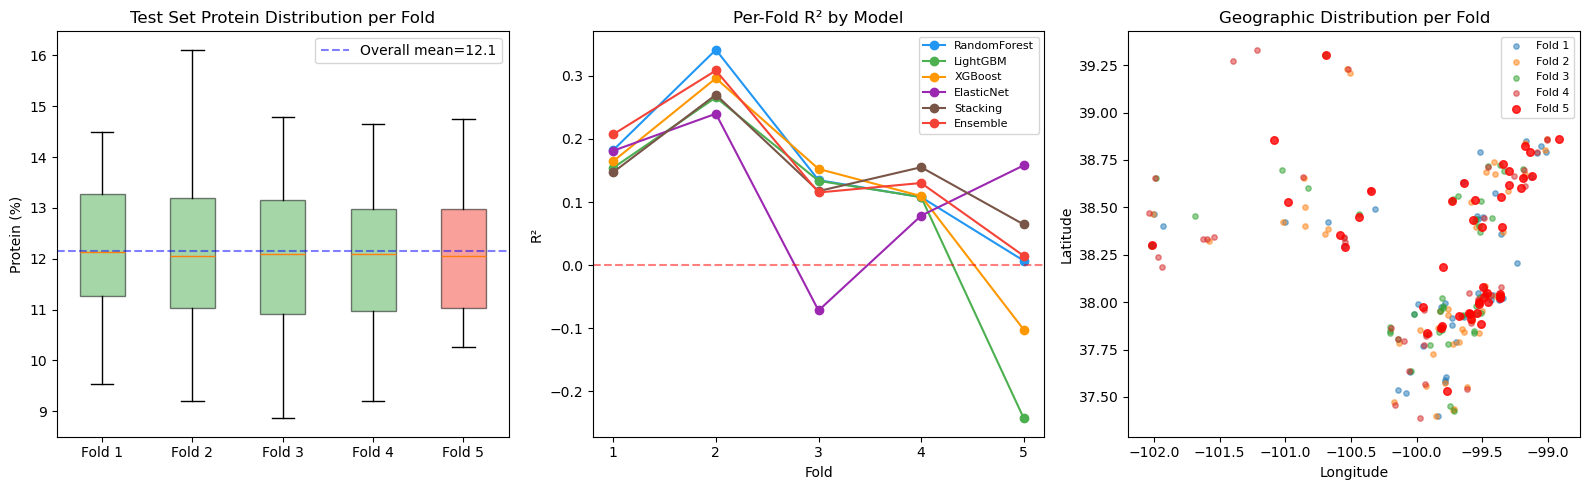

Worst fold: Fold 5 (mean R² = -0.017)


In [9]:
# Visualize fold diagnostics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Identify worst fold dynamically (lowest mean R² across all models)
all_model_r2 = {}
for model_name in cv_results['summary']:
    r2_vals = cv_results['summary'][model_name].get('R2', [])
    if r2_vals:
        for fold_idx, r2 in enumerate(r2_vals):
            all_model_r2.setdefault(fold_idx, []).append(r2)
worst_fold_idx = min(all_model_r2, key=lambda k: np.mean(all_model_r2[k]))

# 1. Protein distribution per fold (boxplot)
fold_labels = []
fold_proteins = []
for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X.values, y_binned)):
    fold_proteins.append(y[test_idx])
    fold_labels.append(f"Fold {fold_idx+1}")

bp = axes[0].boxplot(fold_proteins, labels=fold_labels, patch_artist=True)
colors = ['#F44336' if i == worst_fold_idx else '#4CAF50' for i in range(len(fold_labels))]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
axes[0].set_ylabel('Protein (%)')
axes[0].set_title('Test Set Protein Distribution per Fold')
axes[0].axhline(y=np.mean(y), color='blue', linestyle='--', alpha=0.5, label=f'Overall mean={np.mean(y):.1f}')
axes[0].legend()

# 2. Per-fold R² for all models
model_colors = {'RandomForest': '#2196F3', 'LightGBM': '#4CAF50', 
                'XGBoost': '#FF9800', 'ElasticNet': '#9C27B0',
                'Stacking': '#795548', 'Ensemble': '#F44336'}
for model_name in cv_results['summary']:
    r2_vals = cv_results['summary'][model_name].get('R2', [])
    if r2_vals:
        axes[1].plot(range(1, len(r2_vals)+1), r2_vals, 'o-', 
                     label=model_name, color=model_colors.get(model_name, 'gray'))
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('R²')
axes[1].set_title('Per-Fold R² by Model')
axes[1].set_xticks(range(1, outer_splits+1))
axes[1].legend(fontsize=8)

# 3. Geographic distribution per fold
if 'centroid_lat' in df.columns and 'centroid_lon' in df.columns:
    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X.values, y_binned)):
        fold_df = df.iloc[test_idx]
        color = 'red' if fold_idx == worst_fold_idx else f'C{fold_idx}'
        alpha = 0.8 if fold_idx == worst_fold_idx else 0.5
        size = 30 if fold_idx == worst_fold_idx else 15
        axes[2].scatter(fold_df['centroid_lon'], fold_df['centroid_lat'], 
                       c=color, alpha=alpha, s=size, label=f'Fold {fold_idx+1}')
    axes[2].set_xlabel('Longitude')
    axes[2].set_ylabel('Latitude')
    axes[2].set_title('Geographic Distribution per Fold')
    axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'../figures/06_fold_diagnostics_{AGGREGATION_MODE}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Worst fold: Fold {worst_fold_idx + 1} (mean R² = {np.mean(all_model_r2[worst_fold_idx]):.3f})")

## 4. Predictions vs Observations

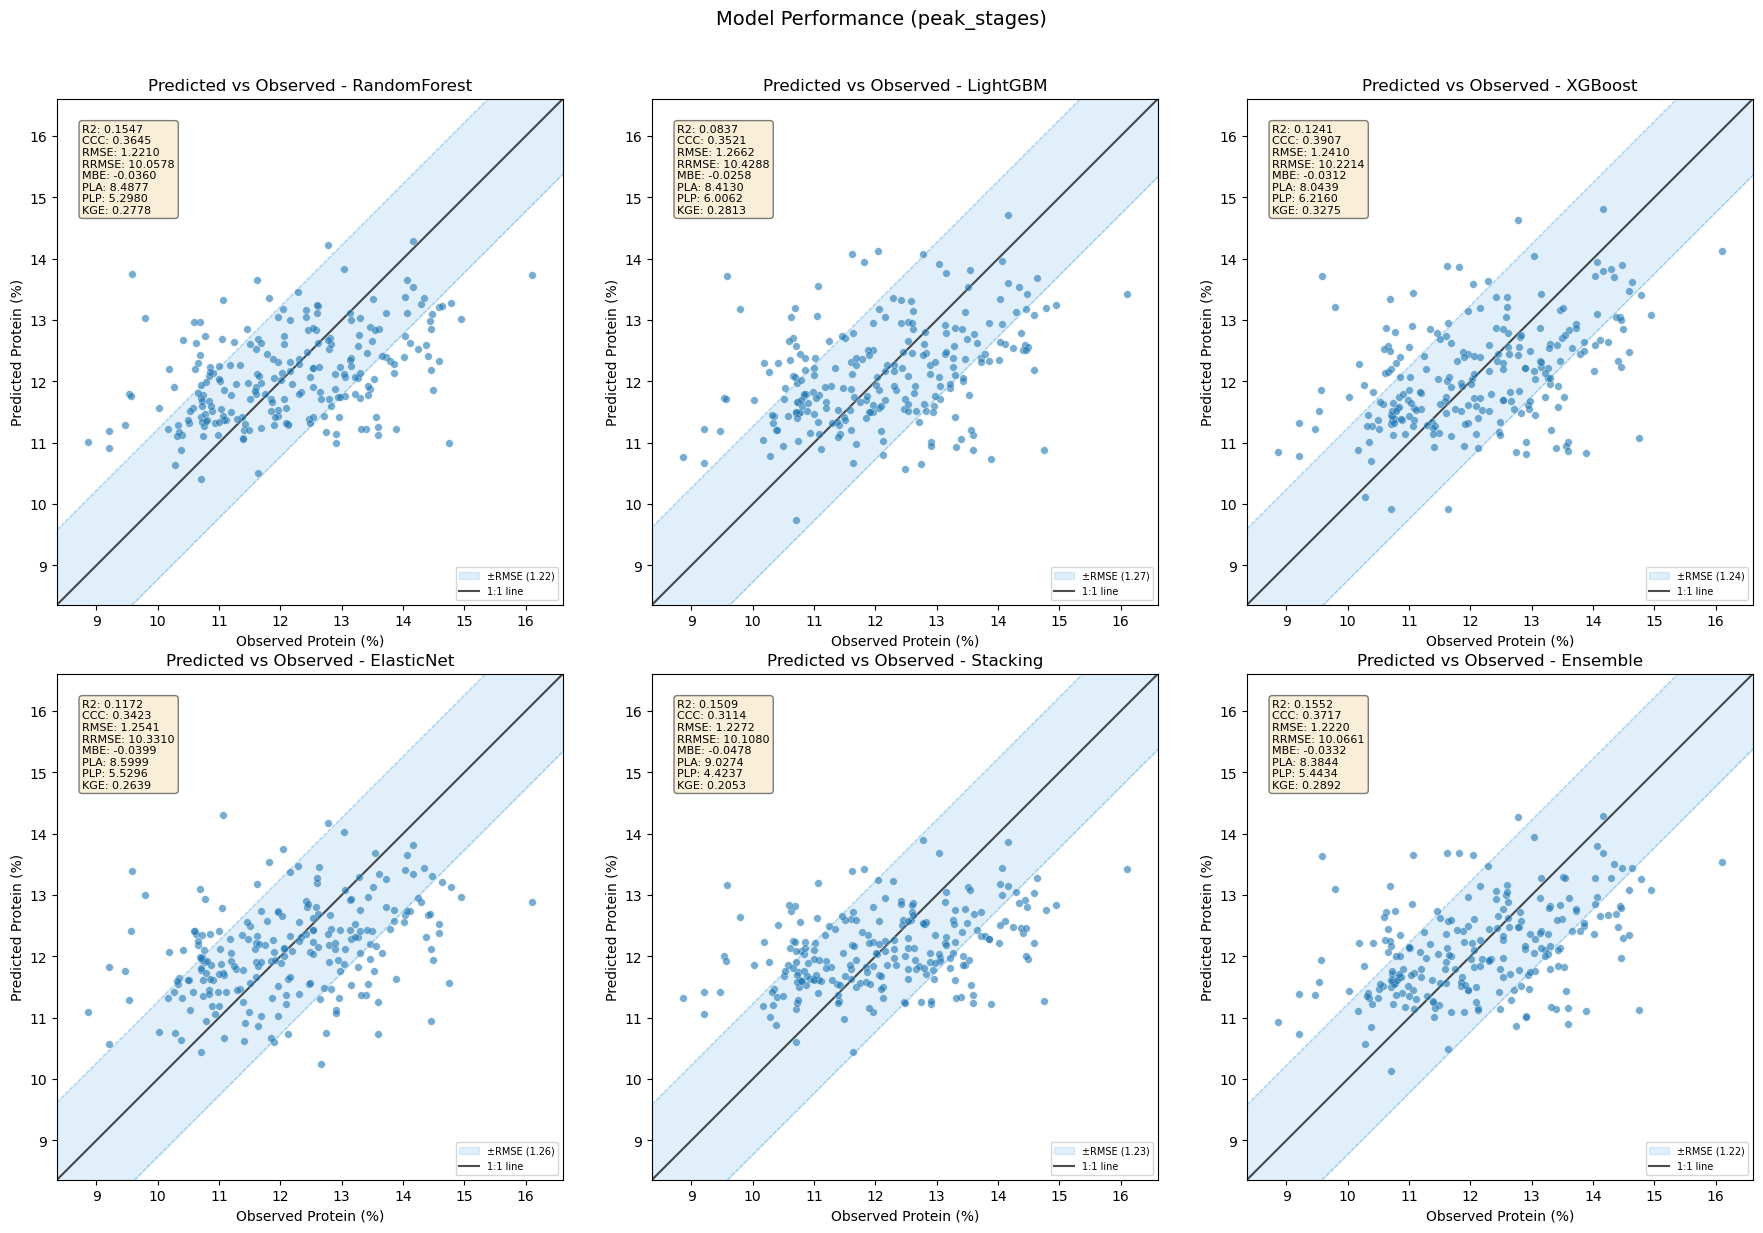

In [10]:
model_names = [m for m in cv_results['summary'].keys() if cv_results['summary'][m]]
n_models = len(model_names)
n_cols = min(3, n_models)
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
if n_models == 1:
    axes = np.array([axes])
axes = axes.flatten()

# Prediction interval options: "rmse", "95ci", "10pct", "20pct", or None
PREDICTION_INTERVAL = "rmse"  # Shows ±RMSE band around 1:1 line

for i, model_name in enumerate(model_names):
    metrics = {k: np.mean(v) for k, v in cv_results['summary'][model_name].items() if v}
    
    # Collect OOF predictions for this model
    oof = cv_results['oof_predictions']
    pred_col = f'y_pred_{model_name}'
    if pred_col in oof.columns:
        y_true_oof = oof['y_true'].values
        y_pred_oof = oof[pred_col].values
        mask = np.isfinite(y_true_oof) & np.isfinite(y_pred_oof)
        plot_predictions_vs_obs(
            y_true_oof[mask], y_pred_oof[mask], 
            model_name, axes[i], metrics,
            prediction_interval=PREDICTION_INTERVAL
        )
    else:
        axes[i].set_title(model_name)
        axes[i].text(0.5, 0.5, 'No OOF predictions', ha='center', va='center', transform=axes[i].transAxes)

for j in range(len(model_names), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Model Performance ({AGGREGATION_MODE})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'../figures/06_predictions_vs_obs_{AGGREGATION_MODE}.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Importance

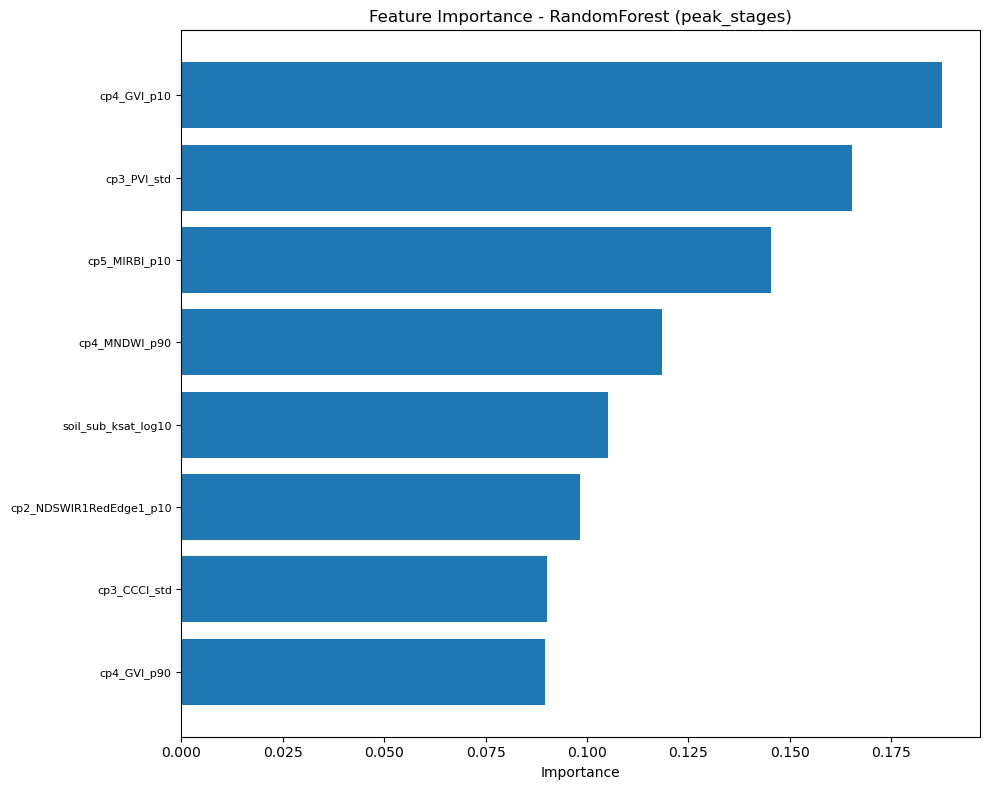

In [11]:
# Get feature importance from the best fold of the best model (excluding Ensemble/Stacking)
# Filter out Ensemble and Stacking as they don't have simple feature importances
base_models = {k: v for k, v in cv_results['summary'].items() 
               if k not in ['Ensemble', 'Stacking'] and v.get('RMSE')}

if base_models:
    best_model_name = min(base_models.items(), 
                          key=lambda x: np.mean(x[1].get('RMSE', [999])))[0]

    # Find the best fold for this model
    best_fold_idx = 0
    best_r2 = -999
    for i, fold in enumerate(cv_results['fold_results']):
        if best_model_name in fold:
            r2 = fold[best_model_name].get('test_metrics', {}).get('R2', -999)
            if r2 > best_r2:
                best_r2 = r2
                best_fold_idx = i

    best_fold = cv_results['fold_results'][best_fold_idx]
    
    # Use per-fold features if available, otherwise global feature_names
    if 'per_fold_features' in cv_results:
        fold_feature_names = cv_results['per_fold_features'][best_fold_idx]
    else:
        fold_feature_names = cv_results['feature_names']
    
    if best_model_name in best_fold and best_fold[best_model_name].get('fitted_model') is not None:
        model = best_fold[best_model_name]['fitted_model']
        
        if hasattr(model, 'feature_importances_'):
            fig, ax = plt.subplots(figsize=(10, 8))
            plot_feature_importance(
                model.feature_importances_,
                fold_feature_names,
                top_n=25,
                title=f'Feature Importance - {best_model_name} ({AGGREGATION_MODE})',
                ax=ax,
            )
            plt.tight_layout()
            plt.savefig(f'../figures/06_feature_importance_{AGGREGATION_MODE}.png', dpi=150, bbox_inches='tight')
            plt.show()
        elif hasattr(model, 'coef_'):
            # For linear models like ElasticNet
            fig, ax = plt.subplots(figsize=(10, 8))
            coef_abs = np.abs(model.coef_)
            plot_feature_importance(
                coef_abs,
                fold_feature_names,
                top_n=25,
                title=f'Feature Coefficients (abs) - {best_model_name} ({AGGREGATION_MODE})',
                ax=ax,
            )
            plt.tight_layout()
            plt.savefig(f'../figures/06_feature_importance_{AGGREGATION_MODE}.png', dpi=150, bbox_inches='tight')
            plt.show()
        else:
            print(f"{best_model_name} does not have feature_importances_ or coef_ attribute")
    else:
        print(f"No fitted model available for {best_model_name}")
else:
    print("No base models with RMSE metrics available")

## 6. Save Results

In [12]:
# Save summary
summary_dict = {}
for model_name, metrics in cv_results['summary'].items():
    summary_dict[model_name] = {k: {'mean': float(np.mean(v)), 'std': float(np.std(v, ddof=1)) if len(v) > 1 else 0.0} for k, v in metrics.items() if v}

with open(f'../models/results_{AGGREGATION_MODE}.json', 'w') as f:
    json.dump(summary_dict, f, indent=2)

# Save OOF predictions
cv_results['oof_predictions'].to_csv(f'../models/oof_predictions_{AGGREGATION_MODE}.csv', index=False)

# Save best model
if best_model_name in best_fold and best_fold[best_model_name]['fitted_model'] is not None:
    joblib.dump(best_fold[best_model_name]['fitted_model'], 
                f'../models/{best_model_name}_best_{AGGREGATION_MODE}.joblib')

print(f"Saved results to models/results_{AGGREGATION_MODE}.json")
print(f"Saved OOF predictions to models/oof_predictions_{AGGREGATION_MODE}.csv")
print(f"\nNotebook 06 complete!")

Saved results to models/results_peak_stages.json
Saved OOF predictions to models/oof_predictions_peak_stages.csv

Notebook 06 complete!
